# Did Remote Work Change Melbourne's Location Premium?
## An Analysis of Property Price Gradients Before, During, and After COVID-19

### 1. Introduction

The COVID-19 pandemic fundamentally changed how people work and live. 
With the widespread adoption of remote work, the daily commute to the 
central business district became less central to residential location 
decisions. This raises a natural question: did the value of living 
close to the CBD change as a result?

This study investigates whether the pandemic altered Melbourne's 
residential property price gradients. Specifically, it examines whether 
suburbs farther from the CBD and with limited public transport access 
appreciated more during the pandemic than they had before.

The analysis is inspired by Sheard (2024), who documented a significant 
flattening of Sydney's property price gradient during COVID-19, finding 
that the premium on proximity to the CBD decreased after 2019 and 
persisted beyond the end of pandemic measures. This study replicates 
that logic for Melbourne using publicly available data from the 
Victorian Property Sales Report.

**Research question:** Did remote work reduce the location premium 
in Melbourne? Did suburbs farther from the CBD appreciate more 
during the pandemic relative to the pre-pandemic period?

### 2. Data

This study uses data from the Victorian Property Sales Report, 
a publicly available dataset published by the Victorian Government 
containing median house prices by suburb across Victoria, Australia.

The dataset covers the period from 2013 to 2023 and includes 
median sale prices for residential properties at the suburb level. 
After filtering for metropolitan Melbourne only, the final sample 
comprises 393 suburbs.

Three analytical periods were defined to capture distinct market 
phases:

- **Pre-pandemic (2017–2019):** A period of market correction 
following years of strong growth.
- **Pandemic (2019–2021):** Widespread remote work adoption and 
significant price appreciation.
- **Post-pandemic (2021–2023):** Market stabilisation under rising 
interest rates.

Two key variables were constructed to measure location 
characteristics:

- **Distance to CBD:** Suburbs were grouped into rings of 10 km 
from the Melbourne CBD (Inner City, Inner Suburbs, Middle Ring, 
Outer Ring, and Fringe).
- **Transport access:** Suburbs were classified by public transport 
availability into four categories: Train and Tram, Train Only, 
Tram Only, and None.

The dependent variable in all analyses is the percentage change 
in median house price within each period.

### 3. Method

The analysis proceeds in two stages.

The first stage consists of descriptive statistics. Median price 
appreciation is calculated for each suburb across the three 
periods and compared across distance rings and transport 
categories. This allows for an initial assessment of whether 
location characteristics are associated with differential 
price appreciation.

The second stage estimates three separate Ordinary Least Squares 
(OLS) regressions, one for each analytical period:

Price appreciation = β0 + β1 × Distance to CBD + β2 × Train access + ε

Where distance to CBD is measured in kilometres and train access 
is a binary variable equal to 1 if the suburb has a train station 
and 0 otherwise.

Running the model separately for each period allows for a direct 
comparison of whether the relationship between location and price 
appreciation changed before, during, and after the pandemic.

This approach is a simplified version of the hedonic pricing 
methodology used by Sheard (2024), adapted to the available data.

### Data Preparation

The raw dataset includes suburbs from across Victoria, including 
regional areas. For this analysis, only metropolitan Melbourne 
suburbs were retained, defined as those within 80 km of the CBD. 
This reduced the sample from 786 to 393 suburbs.

Additionally, price columns for 2013 to 2019 required type 
conversion from string to numeric, as some entries contained 
non-numeric placeholders.

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('Houses_Melbs.csv', encoding='latin1')
df.head()


,Locality,2013,2014,2015,2016,2017,2018,2019,2020,2021,...,Train,Tram,Group,Pré,Pan,Pós,Transport,Train.1,Tram.1,Bouth
0,ABBOTSFORD,792500,862500,925000,1187500,1280000,1192500,1050000,1200000,1365000,...,Não,Sim,Inner city,-17.97%,30.00%,-8.42%,Tram only,0.0,1.0,0.0
1,AINTREE,-,-,600000,600000,571000,557500,575000,616000,713500,...,NaN,NaN,Regional Victoria,0.70%,24.09%,4.84%,NaN,NaN,NaN,NaN
2,AIREYS INLET,664000,625500,680000,715000,737500,869000,985000,1132500,1775000,...,NaN,NaN,Regional Victoria,33.56%,80.20%,-5.63%,NaN,NaN,NaN,NaN
3,AIRPORT WEST,532000,575000,635000,742000,845000,845000,795000,812500,960000,...,Não,Não,Inner suburbs,-5.92%,20.75%,-1.56%,None,0.0,0.0,0.0
4,ALBANVALE,313000,328000,345000,439000,526500,546000,512000,545000,610000,...,Não,Não,Inner suburbs,-2.75%,19.14%,-2.46%,None,0.0,0.0,0.0


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786 entries, 0 to 785
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Locality   786 non-null    object 
 1   2013       786 non-null    object 
 2   2014       786 non-null    object 
 3   2015       786 non-null    object 
 4   2016       786 non-null    object 
 5   2017       786 non-null    object 
 6   2018       786 non-null    object 
 7   2019       786 non-null    object 
 8   2020       786 non-null    int64  
 9   2021       786 non-null    int64  
 10  2022       786 non-null    int64  
 11  2023       786 non-null    int64  
 12  Dist       786 non-null    object 
 13  Train      393 non-null    object 
 14  Tram       393 non-null    object 
 15  Group      786 non-null    object 
 16  Pré        786 non-null    object 
 17  Pan        786 non-null    object 
 18  Pós        786 non-null    object 
 19  Transport  393 non-null    object 
 20  Train.1   

In [3]:
df = df[df['Group'] != 'Regional Victoria']
print(f"Subúrbios de Melbourne: {len(df)}")

Subúrbios de Melbourne: 393


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 393 entries, 0 to 782
Data columns (total 23 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Locality   393 non-null    object 
 1   2013       393 non-null    object 
 2   2014       393 non-null    object 
 3   2015       393 non-null    object 
 4   2016       393 non-null    object 
 5   2017       393 non-null    object 
 6   2018       393 non-null    object 
 7   2019       393 non-null    object 
 8   2020       393 non-null    int64  
 9   2021       393 non-null    int64  
 10  2022       393 non-null    int64  
 11  2023       393 non-null    int64  
 12  Dist       393 non-null    object 
 13  Train      393 non-null    object 
 14  Tram       393 non-null    object 
 15  Group      393 non-null    object 
 16  Pré        393 non-null    object 
 17  Pan        393 non-null    object 
 18  Pós        393 non-null    object 
 19  Transport  393 non-null    object 
 20  Train.1   

In [5]:
print(df['Dist'].unique())

['3' '14' '20' '12' '7' '19' '11' '15' '6' '5' '28' '4' '10' '25' '26'
 '48' '47' '18' '40' '41' '9' '13' '42' '57' '16' '53' '30' '38' '44' '8'
 '22' '17' '1' '2' '31' '33' '37' '46' '45' '43' '29' '27' '36' '34' '55'
 '50' '24' '62' '67' '35' '32' '70' '21' '58' '56' '23' '76' '52']


In [6]:
df[['2017','2019','2021','2023','Dist']].info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 393 entries, 0 to 782
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   2017    393 non-null    object
 1   2019    393 non-null    object
 2   2021    393 non-null    int64 
 3   2023    393 non-null    int64 
 4   Dist    393 non-null    object
dtypes: int64(2), object(3)
memory usage: 18.4+ KB


In [7]:
print(df['2017'].unique()[:20])

['1280000' '845000' '526500' '2150000' '730000' '1560000' '950000'
 '900000' '626500' '825000' '595000' '2300000' '1185000' '1812500'
 '1359000' '1125000' '882500' '742500' '845500' '1385500']


In [8]:
print(df['2019'].unique()[:20])


['1050000' '795000' '512000' '1990000' '675000' '1455000' '890000'
 '857500' '615000' '790000' '572000' '2490000' '1100000' '1641500'
 '994000' '844000' '767500' '810000' '1405000' '2377500']


In [9]:
print(df['Dist'].unique())


['3' '14' '20' '12' '7' '19' '11' '15' '6' '5' '28' '4' '10' '25' '26'
 '48' '47' '18' '40' '41' '9' '13' '42' '57' '16' '53' '30' '38' '44' '8'
 '22' '17' '1' '2' '31' '33' '37' '46' '45' '43' '29' '27' '36' '34' '55'
 '50' '24' '62' '67' '35' '32' '70' '21' '58' '56' '23' '76' '52']


In [10]:
anos = ['2013','2014','2015','2016','2017','2018','2019']

for ano in anos:
    df[ano] = df[ano].astype(str).str.strip().str.replace(',','').str.replace('-','')
    df[ano] = pd.to_numeric(df[ano], errors='coerce')

df['Dist'] = df['Dist'].astype(str).str.strip()
df['Dist'] = pd.to_numeric(df['Dist'], errors='coerce')

print("Conversão feita!")

Conversão feita!


In [11]:
df[['2017','2019','2021','2023','Dist']].info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 393 entries, 0 to 782
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   2017    390 non-null    float64
 1   2019    391 non-null    float64
 2   2021    393 non-null    int64  
 3   2023    393 non-null    int64  
 4   Dist    393 non-null    int64  
dtypes: float64(2), int64(3)
memory usage: 18.4 KB


In [12]:
anos_numericos = ['2013','2014','2015','2016','2017','2018','2019','2020','2021','2022','2023']

df[anos_numericos].describe()

,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
count,3.860000e+02,3.880000e+02,3.880000e+02,3.890000e+02,3.900000e+02,3.910000e+02,3.910000e+02,3.930000e+02,3.930000e+02,3.930000e+02,3.930000e+02
mean,6.425531e+05,7.056611e+05,8.045760e+05,8.919242e+05,1.011821e+06,1.001720e+06,9.622698e+05,1.022391e+06,1.189176e+06,1.197020e+06,1.178579e+06
std,3.470000e+05,4.063642e+05,4.791357e+05,5.391581e+05,5.874294e+05,5.306028e+05,5.261604e+05,5.749242e+05,6.612961e+05,6.198943e+05,6.142784e+05
min,2.130000e+05,1.680000e+05,1.800000e+05,2.760000e+05,3.400000e+05,4.150000e+05,3.350000e+05,3.070000e+05,4.550000e+05,5.000000e+05,4.705000e+05
25%,4.076250e+05,4.288750e+05,4.707500e+05,5.275000e+05,6.200000e+05,6.400000e+05,6.252500e+05,6.520000e+05,7.450000e+05,7.700000e+05,7.500000e+05
50%,5.402500e+05,5.862500e+05,6.757500e+05,7.500000e+05,8.452500e+05,8.400000e+05,8.000000e+05,8.420000e+05,1.000000e+06,1.000000e+06,9.835000e+05
75%,7.500000e+05,8.400000e+05,9.843750e+05,1.079500e+06,1.230000e+06,1.195000e+06,1.123750e+06,1.210000e+06,1.400000e+06,1.435000e+06,1.385000e+06
max,2.875000e+06,3.391000e+06,4.000000e+06,4.900000e+06,5.100000e+06,4.700000e+06,4.600000e+06,5.500000e+06,6.340000e+06,6.205000e+06,5.325000e+06


In [13]:
# Converter colunas de variação para número
df['Pre'] = pd.to_numeric(df['Pré'].str.replace('%','').str.replace(',','.'), errors='coerce') / 100
df['Pan'] = pd.to_numeric(df['Pan'].str.replace('%','').str.replace(',','.'), errors='coerce') / 100
df['Pos'] = pd.to_numeric(df['Pós'].str.replace('%','').str.replace(',','.'), errors='coerce') / 100

print("Valorização média por período:")
print(f"Pré-pandemia:  {df['Pre'].mean():.1%}")
print(f"Pandemia:      {df['Pan'].mean():.1%}")
print(f"Pós-pandemia:  {df['Pos'].mean():.1%}")

Valorização média por período:
Pré-pandemia:  -2.5%
Pandemia:      23.8%
Pós-pandemia:  0.4%


In [14]:
print("Valorização média por grupo de distância:\n")
print(df.groupby('Group')[['Pre','Pan','Pos']].mean().round(3) * 100)

Valorização média por grupo de distância:

               Pre   Pan  Pos
Group                        
Fringe         7.3  25.2  5.0
Inner city    -6.0  23.3 -4.1
Inner suburbs -6.2  23.4 -1.4
Middle ring   -2.3  22.3  2.5
Outer ring     1.6  26.0  4.0


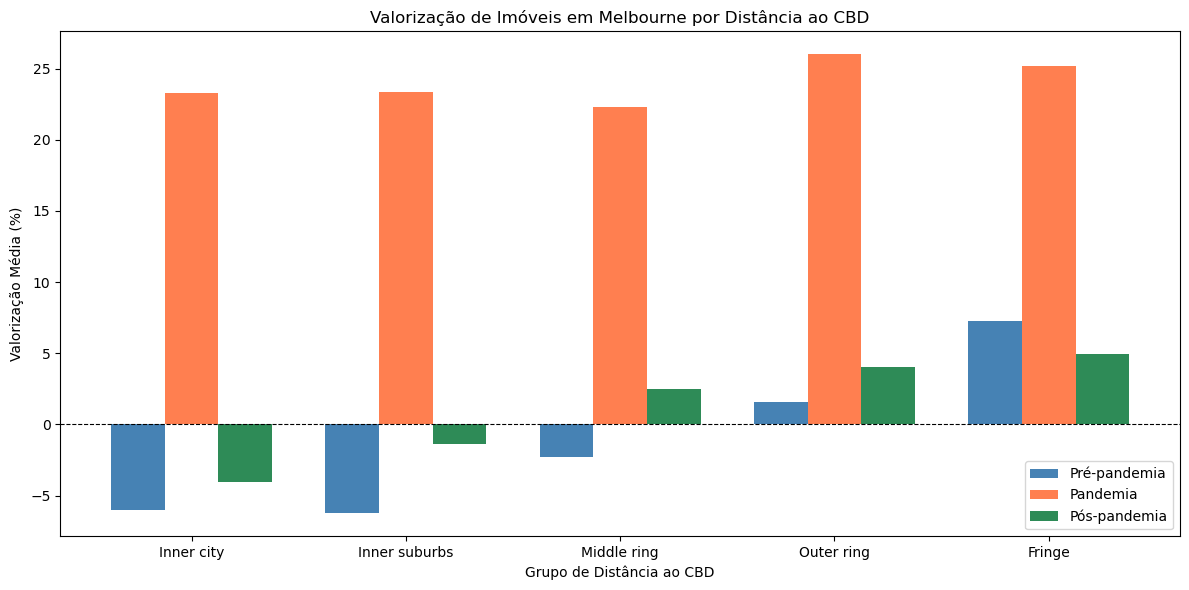

In [15]:
import matplotlib.pyplot as plt
import numpy as np

grupos = ['Inner city', 'Inner suburbs', 'Middle ring', 'Outer ring', 'Fringe']
periodos = ['Pre', 'Pan', 'Pos']
labels = ['Pré-pandemia', 'Pandemia', 'Pós-pandemia']

dados = df.groupby('Group')[periodos].mean() * 100
dados = dados.loc[grupos]

x = np.arange(len(grupos))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width, dados['Pre'], width, label='Pré-pandemia', color='steelblue')
bars2 = ax.bar(x, dados['Pan'], width, label='Pandemia', color='coral')
bars3 = ax.bar(x + width, dados['Pos'], width, label='Pós-pandemia', color='seagreen')

ax.set_xlabel('Grupo de Distância ao CBD')
ax.set_ylabel('Valorização Média (%)')
ax.set_title('Valorização de Imóveis em Melbourne por Distância ao CBD')
ax.set_xticks(x)
ax.set_xticklabels(grupos)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

In [16]:
print("Valorização média por categoria de transporte:\n")
print(df.groupby('Transport')[['Pre','Pan','Pos']].mean().round(3) * 100)

Valorização média por categoria de transporte:

                Pre   Pan  Pos
Transport                     
None           -0.5  23.7  2.4
Train and Tram -7.5  22.9 -3.5
Train only     -4.7  25.1 -0.9
Tram only      -3.4  20.1 -4.6


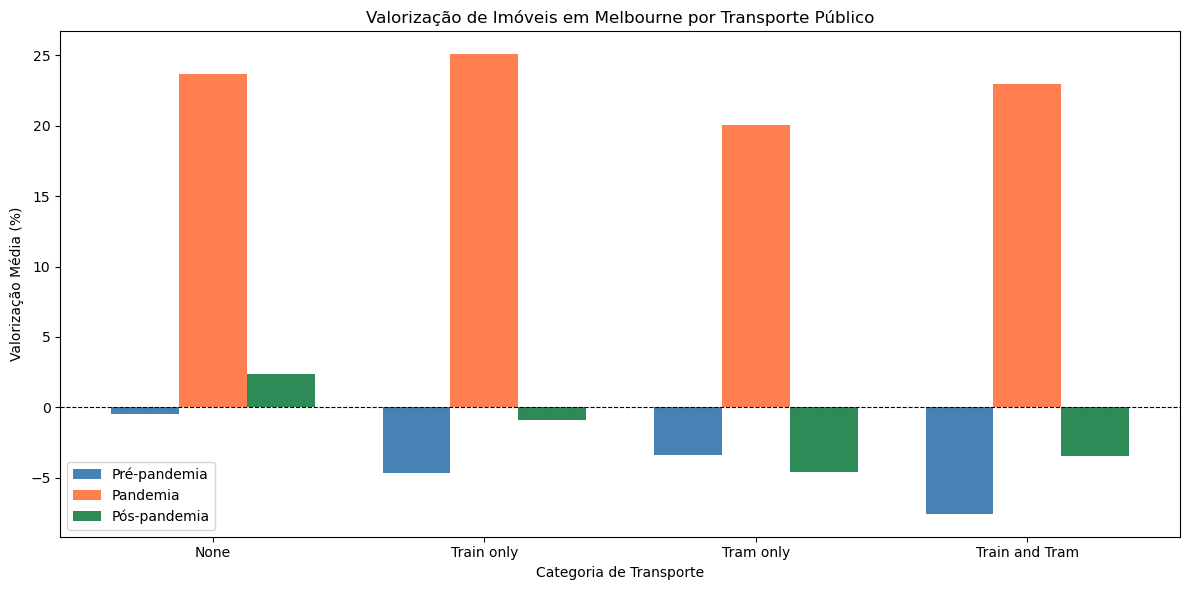

In [17]:
categorias = ['None', 'Train only', 'Tram only', 'Train and Tram']
dados_t = df.groupby('Transport')[['Pre','Pan','Pos']].mean() * 100
dados_t = dados_t.loc[categorias]

x = np.arange(len(categorias))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - width, dados_t['Pre'], width, label='Pré-pandemia', color='steelblue')
ax.bar(x, dados_t['Pan'], width, label='Pandemia', color='coral')
ax.bar(x + width, dados_t['Pos'], width, label='Pós-pandemia', color='seagreen')

ax.set_xlabel('Categoria de Transporte')
ax.set_ylabel('Valorização Média (%)')
ax.set_title('Valorização de Imóveis em Melbourne por Transporte Público')
ax.set_xticks(x)
ax.set_xticklabels(categorias)
ax.legend()
ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

### 4. Results

#### 4.1 Descriptive Statistics

Melbourne's property market behaved very differently across the 
three periods. In the pre-pandemic period, the average suburb 
experienced a slight price decline of 2.5%. During the pandemic, 
prices surged by an average of 23.8%. In the post-pandemic period, 
the market stabilised with an average appreciation of just 0.4%.

This pattern was not uniform across the city. Suburbs in the 
Fringe and Outer Ring appreciated more than Inner City suburbs 
both during and after the pandemic, suggesting a shift in 
location preferences.

| Period         | Mean   | Median | Std Dev |
|----------------|--------|--------|---------|
| Pre-pandemic   | -2.5%  | -3.0%  | 9.4%    |
| Pandemic       | 23.8%  | 23.1%  | 11.0%   |
| Post-pandemic  | 0.4%   | 0.0%   | 7.5%    |

#### 4.2 Appreciation by Distance Ring

Suburbs closer to the CBD underperformed during and after the 
pandemic relative to more distant suburbs. The Inner City group 
showed negative appreciation in both the pre-pandemic and 
post-pandemic periods, while the Fringe group maintained positive 
appreciation across all three periods.

| Group         | Pre    | Pandemic | Post   |
|---------------|--------|----------|--------|
| Inner City    | -6.0%  | 23.3%    | -4.1%  |
| Inner Suburbs | -6.2%  | 23.4%    | -1.4%  |
| Middle Ring   | -2.3%  | 22.3%    | 2.5%   |
| Outer Ring    | 1.6%   | 26.0%    | 4.0%   |
| Fringe        | 7.3%   | 25.2%    | 5.0%   |

#### 4.3 Appreciation by Transport Category

Suburbs without any public transport access outperformed 
connected suburbs in the post-pandemic period, with an average 
appreciation of 2.4% compared to negative returns for suburbs 
with tram access.

| Transport     | Pre    | Pandemic | Post   |
|---------------|--------|----------|--------|
| Train and Tram| -7.5%  | 22.9%    | -3.5%  |
| Train Only    | -4.7%  | 25.1%    | -0.9%  |
| Tram Only     | -3.4%  | 20.1%    | -4.6%  |
| None          | -0.5%  | 23.7%    | 2.4%   |

#### 4.4 Regression Results

Three OLS regressions were estimated, one for each period, 
using distance to CBD and train access as explanatory variables.

| Period        | R²    | Coef. Distance | p-value | Coef. Train | p-value |
|---------------|-------|----------------|---------|-------------|---------|
| Pre-pandemic  | 0.260 | 0.0030         | 0.000   | -0.0195     | 0.026   |
| Pandemic      | 0.017 | 0.0009         | 0.026   | 0.0215      | 0.068   |
| Post-pandemic | 0.181 | 0.0020         | 0.000   | -0.0123     | 0.095   |

The results reveal a striking pattern. Before the pandemic, 
distance and transport explained 26% of price variation across 
suburbs. During the pandemic, this explanatory power collapsed 
to just 1.7%, suggesting that appreciation was widespread and 
driven by factors not captured in this model. In the post-pandemic 
period, the pattern partially recovered to 18.1%, but train access 
lost statistical significance, suggesting a structural shift in 
how the market values connectivity.

In [18]:
import statsmodels.formula.api as smf

# Criar dummy de trem (1 = tem trem, 0 = não tem)
df['Tem_Trem'] = df['Train'].apply(lambda x: 1 if x == 'Sim' else 0)

print("Pronto!")

Pronto!


In [19]:
modelo_pan = smf.ols('Pan ~ Dist + Tem_Trem', data=df).fit()
print(modelo_pan.summary())

                            OLS Regression Results                            
Dep. Variable:                    Pan   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                  0.012
Method:                 Least Squares   F-statistic:                     3.327
Date:                Wed, 13 May 2026   Prob (F-statistic):             0.0369
Time:                        19:51:38   Log-Likelihood:                 313.05
No. Observations:                 391   AIC:                            -620.1
Df Residuals:                     388   BIC:                            -608.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2100      0.012     17.347      0.0

In [20]:
modelo_pre = smf.ols('Pre ~ Dist + Tem_Trem', data=df).fit()
print("PRÉ-PANDEMIA:")
print(f"R²: {modelo_pre.rsquared:.3f}")
print(modelo_pre.params)
print(f"p-values:\n{modelo_pre.pvalues}\n")

modelo_pos = smf.ols('Pos ~ Dist + Tem_Trem', data=df).fit()
print("PÓS-PANDEMIA:")
print(f"R²: {modelo_pos.rsquared:.3f}")
print(modelo_pos.params)
print(f"p-values:\n{modelo_pos.pvalues}")

PRÉ-PANDEMIA:
R²: 0.260
Intercept   -0.085546
Dist         0.002994
Tem_Trem    -0.019549
dtype: float64
p-values:
Intercept    2.712224e-19
Dist         9.189210e-23
Tem_Trem     2.631474e-02
dtype: float64

PÓS-PANDEMIA:
R²: 0.181
Intercept   -0.036862
Dist         0.001995
Tem_Trem    -0.012283
dtype: float64
p-values:
Intercept    1.584028e-06
Dist         1.145041e-15
Tem_Trem     9.474795e-02
dtype: float64


In [21]:
import pandas as pd

resumo = pd.DataFrame({
    'Período': ['Pré-pandemia', 'Pandemia', 'Pós-pandemia'],
    'R²': [
        round(modelo_pre.rsquared, 3),
        round(modelo_pan.rsquared, 3),
        round(modelo_pos.rsquared, 3)
    ],
    'Intercepto': [
        round(modelo_pre.params['Intercept'], 4),
        round(modelo_pan.params['Intercept'], 4),
        round(modelo_pos.params['Intercept'], 4)
    ],
    'Coef. Distância': [
        round(modelo_pre.params['Dist'], 4),
        round(modelo_pan.params['Dist'], 4),
        round(modelo_pos.params['Dist'], 4)
    ],
    'p-value Distância': [
        round(modelo_pre.pvalues['Dist'], 4),
        round(modelo_pan.pvalues['Dist'], 4),
        round(modelo_pos.pvalues['Dist'], 4)
    ],
    'Coef. Trem': [
        round(modelo_pre.params['Tem_Trem'], 4),
        round(modelo_pan.params['Tem_Trem'], 4),
        round(modelo_pos.params['Tem_Trem'], 4)
    ],
    'p-value Trem': [
        round(modelo_pre.pvalues['Tem_Trem'], 4),
        round(modelo_pan.pvalues['Tem_Trem'], 4),
        round(modelo_pos.pvalues['Tem_Trem'], 4)
    ]
})

resumo.set_index('Período', inplace=True)
print(resumo.to_string())

                 R²  Intercepto  Coef. Distância  p-value Distância  Coef. Trem  p-value Trem
Período                                                                                      
Pré-pandemia  0.260     -0.0855           0.0030             0.0000     -0.0195        0.0263
Pandemia      0.017      0.2100           0.0009             0.0264      0.0215        0.0675
Pós-pandemia  0.181     -0.0369           0.0020             0.0000     -0.0123        0.0947


In [22]:
desc = df[['Dist', 'Pre', 'Pan', 'Pos']].describe().round(3)

desc.index = ['N', 'Média', 'Desvio Padrão', 'Mínimo', 'Q1', 'Mediana', 'Q3', 'Máximo']
desc.columns = ['Distância ao CBD (km)', 'Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']

desc.loc['Média', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Desvio Padrão', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Mínimo', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Q1', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Mediana', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Q3', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100
desc.loc['Máximo', ['Valorização Pré (%)', 'Valorização Pandemia (%)', 'Valorização Pós (%)']] *= 100

print(desc.to_string())

               Distância ao CBD (km)  Valorização Pré (%)  Valorização Pandemia (%)  Valorização Pós (%)
N                            393.000                390.0                     391.0                393.0
Média                         22.751                 -2.5                      23.8                  0.4
Desvio Padrão                 14.939                  9.4                      11.0                  7.5
Mínimo                         1.000                -48.5                     -41.8                -23.0
Q1                            11.000                 -8.2                      17.7                 -3.7
Mediana                       20.000                 -3.0                      23.1                  0.0
Q3                            32.000                  2.9                      29.6                  5.1
Máximo                        76.000                 28.3                     108.8                 36.4


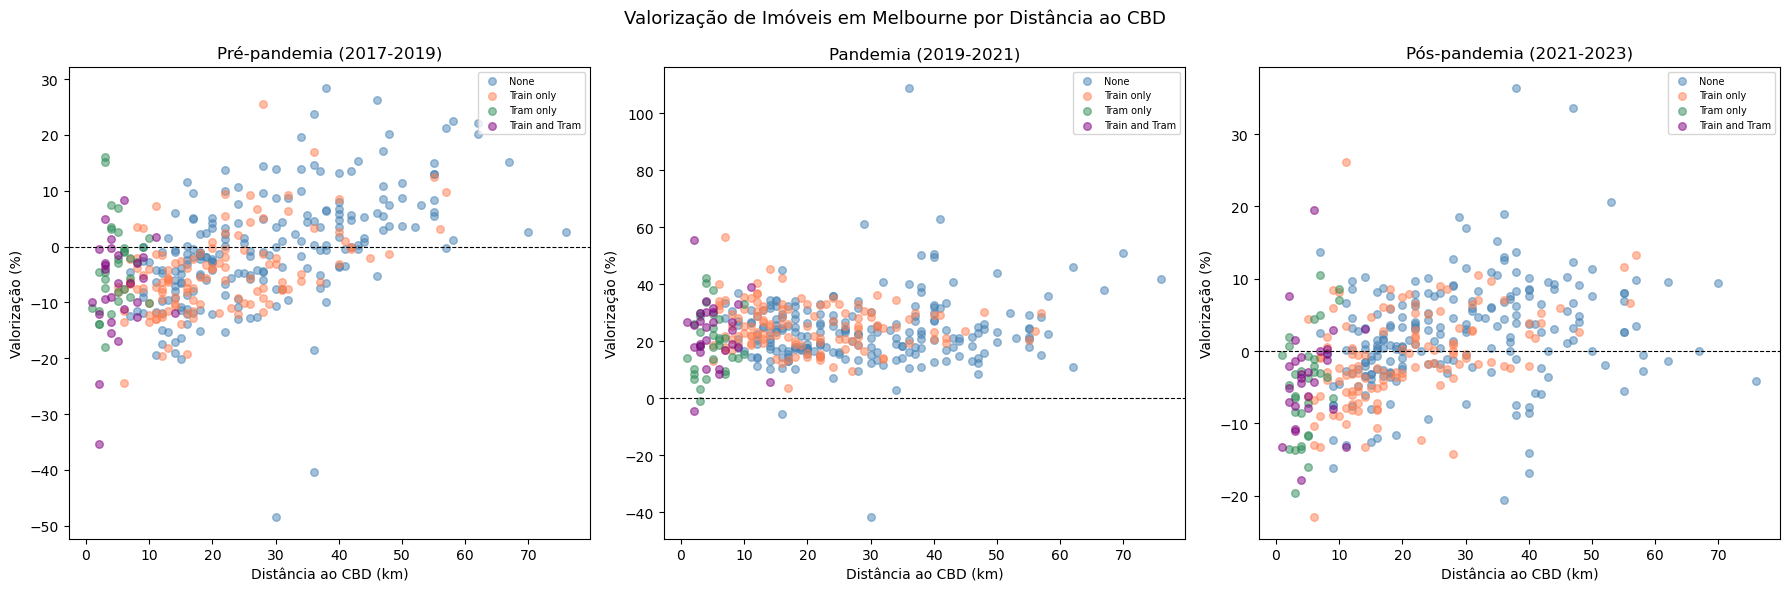

In [23]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=False)

periodos = ['Pre', 'Pan', 'Pos']
titulos = ['Pré-pandemia (2017-2019)', 'Pandemia (2019-2021)', 'Pós-pandemia (2021-2023)']
cores = {'None': 'steelblue', 'Train only': 'coral', 'Tram only': 'seagreen', 'Train and Tram': 'purple'}

for i, (periodo, titulo) in enumerate(zip(periodos, titulos)):
    ax = axes[i]
    for categoria, cor in cores.items():
        subset = df[df['Transport'] == categoria]
        ax.scatter(subset['Dist'], subset[periodo] * 100,
                   c=cor, label=categoria, alpha=0.5, s=30)
    ax.axhline(y=0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(titulo)
    ax.set_xlabel('Distância ao CBD (km)')
    ax.set_ylabel('Valorização (%)')
    ax.legend(fontsize=7)

plt.suptitle('Valorização de Imóveis em Melbourne por Distância ao CBD', fontsize=13)
plt.tight_layout()
plt.show()

### 5. Conclusion

This study investigated whether the COVID-19 pandemic altered 
the relationship between location and property price appreciation 
in metropolitan Melbourne.

The results support the hypothesis that remote work reduced 
the location premium. Before the pandemic, distance to the CBD 
and train access explained 26% of the variation in price 
appreciation across suburbs. During the pandemic, this explanatory 
power collapsed almost entirely, as appreciation became widespread 
and generalised. In the post-pandemic period, the pattern partially 
recovered, but train access lost statistical significance, 
suggesting that connectivity to the CBD became less central to 
residential location decisions.

These findings are broadly consistent with Sheard (2024), who 
documented a similar flattening of Sydney's property price gradient 
during COVID-19. The parallel results across two of Australia's 
largest cities suggest that the shift in location preferences 
may reflect a structural change in how people value urban 
proximity in the post-pandemic era.

### 6. Limitations and Future Work

This analysis has several important limitations.

The data consists of median prices at the suburb level rather 
than individual property transactions. This means the results 
capture broad spatial patterns but cannot control for differences 
in property type, size, or quality within each suburb.

The model uses only two explanatory variables. A more robust 
analysis would include additional controls such as household 
income, school quality, distance to the nearest train station 
rather than a binary indicator, and local infrastructure 
investment, following the approach of Sheard (2024).

The primary objective of this study is to apply data analysis 
techniques to an economically relevant question using publicly 
available data. The results should be interpreted as exploratory 
rather than definitive estimates of Melbourne's location premium.

Future work could extend this analysis by incorporating 
transaction-level data from the Victorian Valuer General, 
adding demographic controls from the ABS Census 2021, and 
applying a difference-in-differences framework to more rigorously 
identify the causal effect of the pandemic on location preferences.

### References

Sheard, N. (2024). Flattening which curve? Property-price 
gradients in New South Wales during the COVID-19 pandemic. 
Regional Studies, Regional Science, 11(1), 153-174.

Victorian Government (2023). Victorian Property Sales Report. 
Department of Transport and Planning.